# MSE433 M4 EDA + Optimization Signals

This notebook performs exploratory data analysis on `MSE433_M4_Data.xlsx` and focuses on optimization-relevant structure:
- data quality and cleaning
- physician and calendar trends
- outlier behavior
- correlation/driver signals
- baseline scheduling insights


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler

sns.set_theme(style="whitegrid", palette="deep")
%matplotlib inline

In [2]:
# 1) Load raw workbook
file_path = 'MSE433_M4_Data.xlsx'
raw = pd.read_excel(file_path, sheet_name='All Data', header=None)
print('Raw shape:', raw.shape)
raw.head(10)

Raw shape: (154, 22)


,0,1,2,3,4,5,6,7,8,9,...,12,13,14,15,16,17,18,19,20,21
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,VARIPULSE CASE DATA,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,CASE #,DATE,PHYSICIAN,PT PREP/INTUBATION,ACCESSS,TSP,PRE-MAP,ABL DURATION,ABL TIME,...,LA DWELL TIME,CASE TIME,AVG CASE TIME,SKIN-SKIN,AVG SKIN-SKIN,POST CARE/EXTUBATION,AVG TURNOVER TIME,PT OUT TIME,PT IN-OUT,Note
3,NaN,NaN,NaN,NaN,Pt-In-Access,(Min),(Min),(Min),(Abl Start-End),(Min),...,(Abl Start-Cath-Out),(Cath In-Out),(Min),(Access to Cath-Out),(Min),(Cath-Out to Pt-Out),(Min),NaN,(Min),NaN
4,NaN,1,2025-01-13 00:00:00,Dr. A,19,6,10,2,28,7.35,...,31,50,NaN,56,NaN,17,NaN,NaN,92,NaN
5,NaN,2,2025-01-14 00:00:00,Dr. A,24,3,7,2,25,6.65,...,29,47,NaN,50,NaN,12,NaN,NaN,86,NaN
6,NaN,3,2025-01-14 00:00:00,Dr. A,22,5,12,2,41,8.4,...,43,37,NaN,42,NaN,12,NaN,NaN,94,NaN
7,NaN,4,2025-01-20 00:00:00,Dr. B,48,5,37,2,41,7.35,...,54,91,NaN,96,NaN,20,NaN,NaN,164,NaN
8,NaN,5,2025-01-20 00:00:00,Dr. B,25,5,16,2,33,7.7,...,33,49,NaN,54,NaN,19,NaN,NaN,98,NaN
9,NaN,6,2025-02-05 00:00:00,Dr. B,25,6,25,3,42,8.4,...,44,89,NaN,75,NaN,20,NaN,NaN,120,NaN


## Why this dataset needs custom parsing

The sheet contains non-data rows. The true column names are in row index `2` (0-based),
and case rows start at index `4`.

In [3]:
# 2) Load + clean to canonical columns
def load_m4_data(path):
    raw = pd.read_excel(path, sheet_name='All Data', header=None)
    headers = raw.iloc[2].tolist()
    df = raw.iloc[4:].copy().reset_index(drop=True)
    df.columns = headers

    if 'Unnamed: 0' in df.columns:
        df = df.drop(columns=['Unnamed: 0'])

    rename_map = {
        'CASE #': 'case_id',
        'DATE': 'date',
        'PHYSICIAN': 'physician',
        'PT PREP/INTUBATION': 'pt_prep_intubation',
        'ACCESSS': 'access',
        'TSP': 'tsp',
        'PRE-MAP': 'pre_map',
        'ABL DURATION': 'abl_duration',
        'ABL TIME': 'abl_time',
        '#ABL': 'abl_count',
        '#APPLICATIONS': 'abl_applications',
        'LA DWELL TIME': 'la_dwell',
        'CASE TIME': 'case_time',
        'AVG CASE TIME': 'avg_case_time',
        'SKIN-SKIN': 'skin_skin',
        'AVG SKIN-SKIN': 'avg_skin_skin',
        'POST CARE/EXTUBATION': 'post_care_extubation',
        'AVG TURNOVER TIME': 'avg_turnover_time',
        'PT OUT TIME': 'pt_out_time',
        'PT IN-OUT': 'pt_in_out',
        'Note': 'note'
    }
    df = df.rename(columns=rename_map)

    df = df[df['case_id'].notna()].copy().reset_index(drop=True)

    df['date'] = pd.to_datetime(df['date'], errors='coerce')

    for c in [c for c in df.columns if c not in ['date', 'physician', 'note', 'case_id']]:
        df[c] = pd.to_numeric(df[c], errors='coerce')

    df['case_id'] = df['case_id'].astype('Int64')
    return df


df = load_m4_data(file_path)
print('Loaded rows:', len(df))
print('Bad dates:', df['date'].isna().sum())
if df['date'].isna().any():
    display(df[df['date'].isna()][['case_id', 'physician']])


Loaded rows: 150
Bad dates: 1


,case_id,physician
76,77,Dr. C


## Data quality check
Inspect missingness and identify usable fields for modeling/scheduling.

In [4]:
# 3) Missingness and base counts
quality = df.isna().mean().sort_values(ascending=False).to_frame(name='missing_rate')
quality['missing_pct'] = (quality['missing_rate'] * 100).round(1)
display(quality)

print('Rows by physician:')
print(df['physician'].value_counts())

monthly = df.dropna(subset=['date']).assign(month=df['date'].dt.to_period('M')).groupby('month').size().sort_index()
print('Monthly case volume:')
print(monthly)


,missing_rate,missing_pct
NaN,1.000000,100.0
pt_out_time,1.000000,100.0
avg_turnover_time,0.960000,96.0
avg_case_time,0.886667,88.7
avg_skin_skin,0.886667,88.7
note,0.840000,84.0
post_care_extubation,0.040000,4.0
tsp,0.033333,3.3
pre_map,0.033333,3.3
abl_duration,0.033333,3.3


Rows by physician:
physician
Dr. A    70
Dr. B    65
Dr. C    15
Name: count, dtype: int64
Monthly case volume:
month
2025-01     5
2025-02     6
2025-03     4
2025-04    15
2025-05    13
2025-06    21
2025-07    24
2025-08    23
2025-09    28
2025-10    10
Freq: M, dtype: int64


## Univariate structure and outliers
Focus on time-critical operational metrics first.

In [5]:
# 4) Core metric summary
metric_cols = [
    'pt_prep_intubation', 'access', 'tsp', 'pre_map', 'abl_duration',
    'abl_time', 'abl_count', 'abl_applications', 'la_dwell',
    'case_time', 'skin_skin', 'post_care_extubation', 'pt_in_out'
]
summary = df[metric_cols].describe(percentiles=[0.25,0.5,0.75]).T
display(summary[['mean', 'std', 'min', '25%', '50%', '75%', 'max']].round(2))

# outlier helper
def iqr_outlier_info(s):
    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1
    lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    mask = (s < lo) | (s > hi)
    return lo, hi, mask

print('IQR outlier summary (n total, n outlier):')
for c in metric_cols:
    s = df[c].dropna()
    lo, hi, mask = iqr_outlier_info(s)
    print(f'{c:24}  n={len(s):3d}  out={mask.sum():3d}  bounds=[{lo:.1f}, {hi:.1f}]')


,mean,std,min,25%,50%,75%,max
pt_prep_intubation,19.17,5.44,10.0,16.00,18.0,22.0,48.0
access,5.36,2.20,2.0,4.00,5.0,6.0,17.0
tsp,5.39,4.82,2.0,3.00,4.0,6.0,37.0
pre_map,2.02,3.96,1.0,1.00,1.0,2.0,48.0
abl_duration,24.03,9.27,12.0,18.00,22.0,28.0,95.0
abl_time,7.41,1.10,5.0,6.65,7.0,8.0,10.5
abl_count,21.13,3.21,15.0,19.00,20.0,23.0,30.0
abl_applications,63.41,9.64,45.0,57.00,60.0,69.0,90.0
la_dwell,25.58,10.58,12.0,19.00,23.0,29.0,103.0
case_time,40.73,17.39,17.0,30.00,37.0,45.0,159.0


IQR outlier summary (n total, n outlier):
pt_prep_intubation        n=145  out=  4  bounds=[7.0, 31.0]
access                    n=145  out=  7  bounds=[1.0, 9.0]
tsp                       n=145  out= 11  bounds=[-1.5, 10.5]
pre_map                   n=145  out=  8  bounds=[-0.5, 3.5]
abl_duration              n=145  out=  4  bounds=[3.0, 43.0]
abl_time                  n=145  out=  3  bounds=[4.6, 10.0]
abl_count                 n=145  out=  3  bounds=[13.0, 29.0]
abl_applications          n=145  out=  3  bounds=[39.0, 87.0]
la_dwell                  n=145  out=  6  bounds=[4.0, 44.0]
case_time                 n=145  out= 11  bounds=[7.5, 67.5]
skin_skin                 n=145  out= 10  bounds=[11.0, 75.0]
post_care_extubation      n=144  out=  4  bounds=[6.0, 22.0]
pt_in_out                 n=145  out=  5  bounds=[31.5, 123.5]


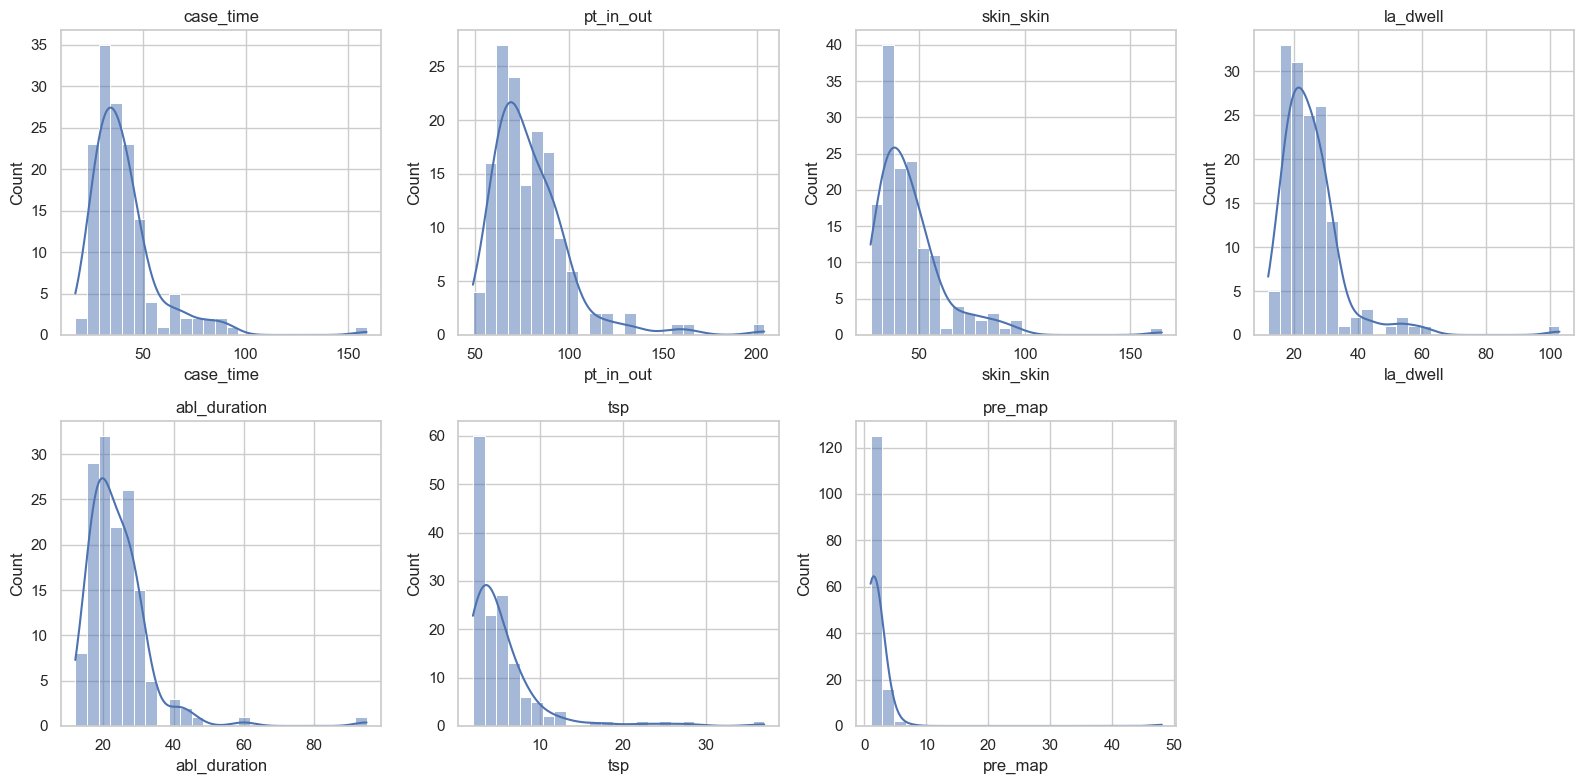

In [6]:
# 5) Distribution plots for operational metrics
plot_cols = ['case_time', 'pt_in_out', 'skin_skin', 'la_dwell', 'abl_duration', 'tsp', 'pre_map']
fig, axes = plt.subplots(2, 4, figsize=(16,8))
axes = axes.flatten()
for ax, c in zip(axes, plot_cols):
    sns.histplot(df[c].dropna(), bins=25, kde=True, ax=ax)
    ax.set_title(c)
for i in range(len(plot_cols), len(axes)):
    axes[i].axis('off')
plt.tight_layout()
plt.show()


## Physician and calendar trends
Compare mean durations and variability by physician and through time.

== case_time ==
           count   mean    std
physician                     
Dr. A         70  33.56   7.69
Dr. B         60  49.37  21.98
Dr. C         15  39.67  14.28
== pt_in_out ==
           count   mean    std
physician                     
Dr. A         70  69.54  10.03
Dr. B         60  91.90  25.73
Dr. C         15  74.67  13.23
== skin_skin ==
           count   mean    std
physician                     
Dr. A         70  38.87   8.34
Dr. B         60  54.63  21.69
Dr. C         15  44.33  14.42
== la_dwell ==
           count   mean    std
physician                     
Dr. A         70  21.94   5.38
Dr. B         60  30.38  13.82
Dr. C         15  23.33   5.78
== tsp ==
           count  mean   std
physician                   
Dr. A         70  4.23  2.77
Dr. B         60  7.23  6.44
Dr. C         15  3.47  1.06
== pre_map ==
           count  mean   std
physician                   
Dr. A         70  1.30  0.52
Dr. B         60  3.02  6.02
Dr. C         15  1.40  0.51
== 

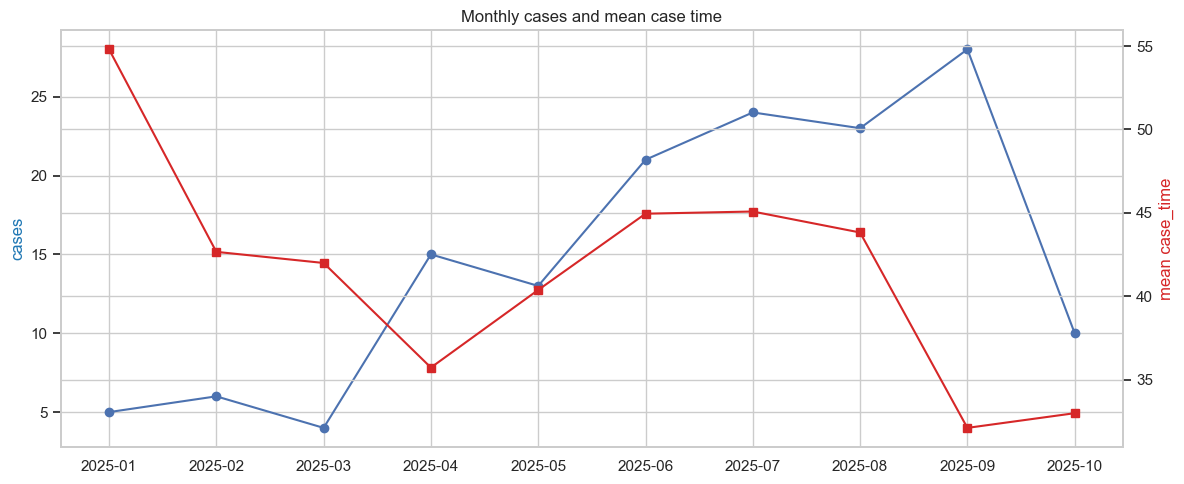

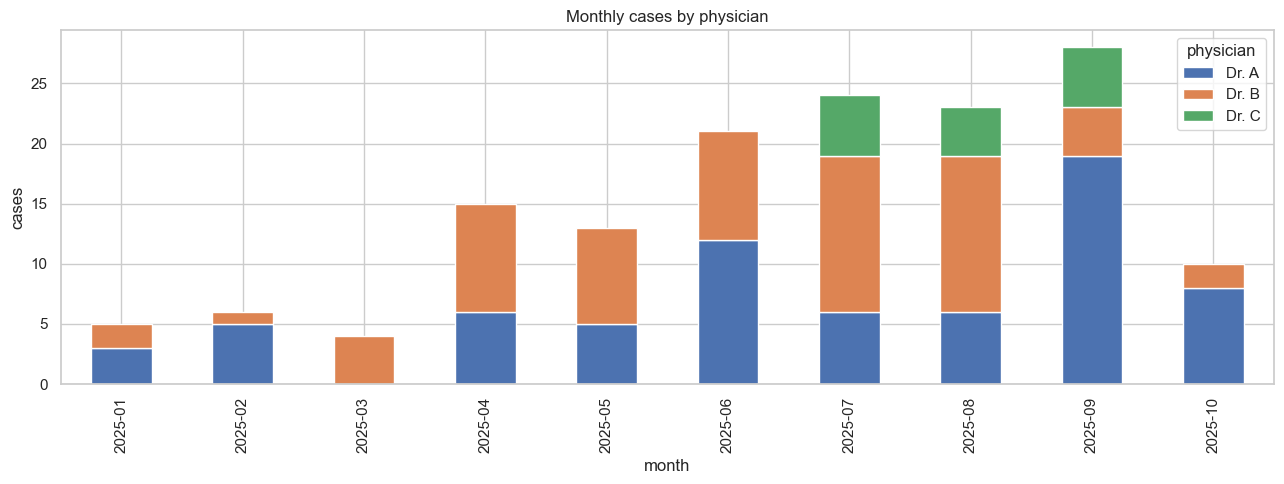

In [7]:
# 6) Physician averages and monthly dynamics
main_cols = ['case_time', 'pt_in_out', 'skin_skin', 'la_dwell', 'tsp', 'pre_map', 'abl_time', 'post_care_extubation']
for c in main_cols:
    print('==', c, '==')
    print(df.groupby('physician')[c].agg(['count', 'mean', 'std']).sort_index().round(2).to_string())

# monthly case_count and mean case_time
t = df.dropna(subset=['date']).assign(month=df['date'].dt.to_period('M')).copy()
monthly = t.groupby('month').agg(cases=('case_id', 'count'), mean_case_time=('case_time', 'mean')).sort_index()
monthly.index = monthly.index.astype(str)

fig, ax1 = plt.subplots(figsize=(12, 5))
ax1.plot(monthly.index, monthly['cases'], marker='o', label='cases')
ax1.set_ylabel('cases', color='tab:blue')
ax2 = ax1.twinx()
ax2.plot(monthly.index, monthly['mean_case_time'], marker='s', color='tab:red', label='mean case_time')
ax2.set_ylabel('mean case_time', color='tab:red')
plt.xticks(rotation=45)
plt.title('Monthly cases and mean case time')
plt.tight_layout()
plt.show()

pm = t.assign(month=t['date'].dt.to_period('M')).groupby(['physician', 'month']).size().unstack(fill_value=0)
pm.columns = pm.columns.astype(str)
pm.T.plot(kind='bar', stacked=True, figsize=(13,5), title='Monthly cases by physician')
plt.ylabel('cases')
plt.tight_layout()
plt.show()


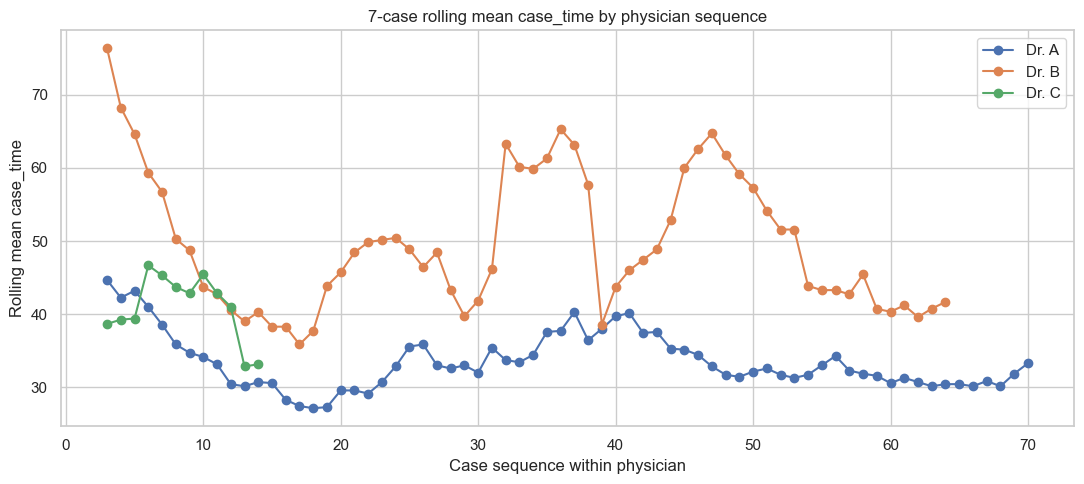

Mean case_time by weekday:
weekday
Monday       69.67
Tuesday      39.03
Wednesday    57.67
Thursday       NaN
Friday         NaN
Name: case_time, dtype: float64


C:\Users\willg\AppData\Local\Temp\ipykernel_2712\1409357032.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  wd['weekday'] = wd['date'].dt.day_name()


In [8]:
# 7) Sequence trend: signal of learning and case-mix drift
df_seq = df.dropna(subset=['date']).sort_values(['physician', 'date', 'case_id']).copy()
df_seq['physician_seq'] = df_seq.groupby('physician').cumcount() + 1

plt.figure(figsize=(11,5))
for p, g in df_seq.groupby('physician'):
    series = g['case_time'].rolling(7, min_periods=3).mean()
    plt.plot(g['physician_seq'], series, marker='o', label=p)
plt.title('7-case rolling mean case_time by physician sequence')
plt.xlabel('Case sequence within physician')
plt.ylabel('Rolling mean case_time')
plt.legend()
plt.tight_layout()
plt.show()

wd = df.dropna(subset=['date'])
wd['weekday'] = wd['date'].dt.day_name()
order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday']
print('Mean case_time by weekday:')
print(wd.groupby('weekday')['case_time'].mean().reindex(order).round(2))


## Correlations and structural drivers

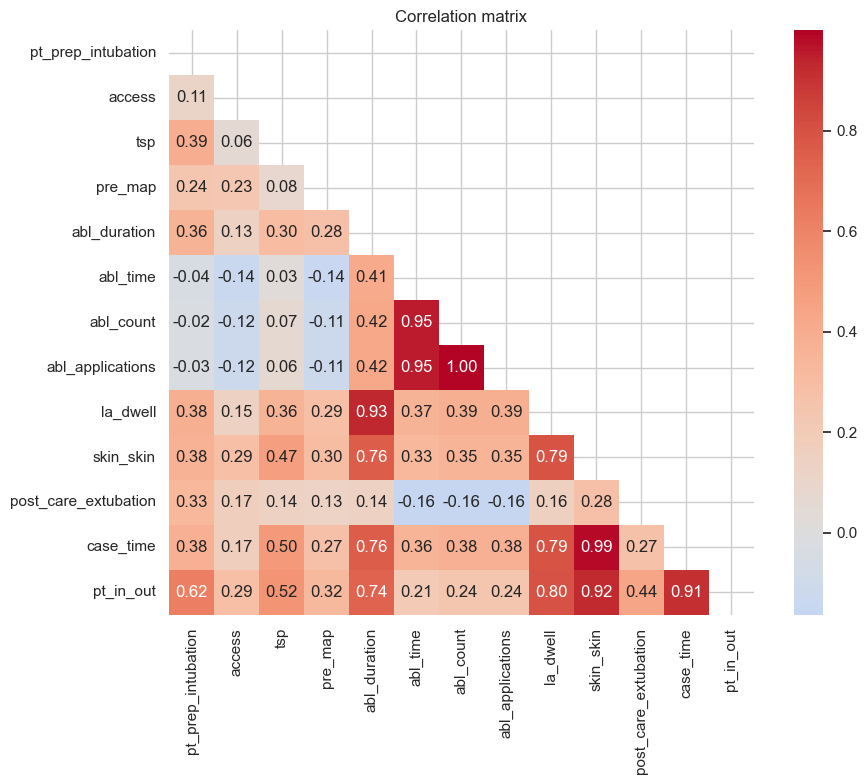

Top correlations with case_time:
skin_skin               0.986910
pt_in_out               0.912618
la_dwell                0.792789
abl_duration            0.761600
tsp                     0.495266
pt_prep_intubation      0.381229
abl_count               0.378575
abl_applications        0.377238
abl_time                0.358174
pre_map                 0.274981
post_care_extubation    0.271173
access                  0.166750
Name: case_time, dtype: float64
Top correlations with pt_in_out:
skin_skin               0.921315
case_time               0.912618
la_dwell                0.796803
abl_duration            0.739120
pt_prep_intubation      0.621366
tsp                     0.522894
post_care_extubation    0.437564
pre_map                 0.323839
access                  0.286037
abl_count               0.239714
abl_applications        0.237771
abl_time                0.207711
Name: pt_in_out, dtype: float64


In [9]:
# 8) Correlation matrix and strong pairwise links
corr_cols = [
    'pt_prep_intubation', 'access', 'tsp', 'pre_map', 'abl_duration',
    'abl_time', 'abl_count', 'abl_applications', 'la_dwell',
    'skin_skin', 'post_care_extubation', 'case_time', 'pt_in_out'
]
corr = df[corr_cols].corr()
plt.figure(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, cmap='coolwarm', center=0, annot=True, fmt='.2f', square=True)
plt.title('Correlation matrix')
plt.tight_layout()
plt.show()

print('Top correlations with case_time:')
print(corr['case_time'].drop('case_time').sort_values(ascending=False))
print('Top correlations with pt_in_out:')
print(corr['pt_in_out'].drop('pt_in_out').sort_values(ascending=False))


## Optimization-oriented baseline model
A linear proxy is useful for ranking and screening lever effects.

In [10]:
# 9) Regression-based signal extraction
features = [
    'pt_prep_intubation', 'access', 'tsp', 'pre_map', 'abl_duration',
    'abl_time', 'abl_count', 'abl_applications', 'la_dwell',
    'skin_skin', 'post_care_extubation'
]
base = df[['case_time'] + features + ['physician']].dropna(subset=['case_time'] + features).copy()
base = pd.get_dummies(base, columns=['physician'], drop_first=True)

X = base.drop(columns=['case_time'])
y = base['case_time']

lr = LinearRegression().fit(X, y)
coef = pd.Series(lr.coef_, index=X.columns).sort_values(key=np.abs, ascending=False)
print('R2:', round(lr.score(X, y), 3))
print('Intercept:', round(lr.intercept_, 3))
print('Largest |coefficients| (unstandardized):')
print(coef.round(3))

scaler = StandardScaler()
Xs = scaler.fit_transform(base[features])
lr_std = LinearRegression().fit(Xs, y)
std_coef = pd.Series(lr_std.coef_, index=features).sort_values(key=np.abs, ascending=False)
print('Standardized coefficients (relative effect strength):')
print(std_coef.round(3))

base['pred_case_time'] = lr.predict(X)
base['residual'] = y - base['pred_case_time']
print('Largest positive residual (underpredicted) cases:')
print(base[['case_time', 'pred_case_time', 'residual']].sort_values('residual', ascending=False).head(10))


R2: 0.99
Intercept: -3.743
Largest |coefficients| (unstandardized):
skin_skin               1.003
access                 -0.976
abl_count              -0.411
physician_Dr. B        -0.392
abl_time                0.236
abl_applications        0.137
tsp                     0.125
post_care_extubation    0.067
abl_duration            0.066
la_dwell               -0.061
physician_Dr. C         0.031
pt_prep_intubation      0.018
pre_map                 0.003
dtype: float64
Standardized coefficients (relative effect strength):
skin_skin               17.400
access                  -2.152
abl_count               -1.349
abl_applications         1.287
la_dwell                -0.697
abl_duration             0.664
tsp                      0.574
abl_time                 0.260
post_care_extubation     0.206
pt_prep_intubation       0.055
pre_map                 -0.014
dtype: float64
Largest positive residual (underpredicted) cases:
     case_time  pred_case_time   residual
5         89.0       72.2

In [11]:
# 10) Additional trend: long-case concentration and operational stress windows
long_th = df['case_time'].quantile(0.90)
long_df = df.dropna(subset=['date']).copy()
long_df['is_long'] = long_df['case_time'] >= long_th
long_df['month'] = long_df['date'].dt.to_period('M')

print('90th percentile threshold for case_time:', round(long_th, 2))
long_share = long_df.groupby('physician')['is_long'].mean().mul(100).round(1)
print('Long case share by physician (%):')
print(long_share)

pivot_long = long_df.pivot_table(index='month', columns='physician', values='is_long', aggfunc='sum', fill_value=0)
pivot_long.index = pivot_long.index.astype(str)
print('Long case count by month x physician:')
print(pivot_long)

scored = df.dropna(subset=['skin_skin', 'la_dwell', 'tsp', 'case_time']).copy()
for c in ['skin_skin', 'la_dwell', 'tsp']:
    scored[f'z_{c}'] = (scored[c] - scored[c].mean()) / scored[c].std(ddof=0)
scored['priority_score'] = scored[['z_skin_skin', 'z_la_dwell', 'z_tsp']].sum(axis=1)
print('Bottom 10 priority-score cases (lower expected burden):')
print(scored.sort_values('priority_score')[['case_id', 'physician', 'date', 'skin_skin', 'la_dwell', 'tsp', 'case_time', 'priority_score']].head(10))
print('Top 10 priority-score cases (higher flow pressure):')
print(scored.sort_values('priority_score', ascending=False)[['case_id', 'physician', 'date', 'skin_skin', 'la_dwell', 'tsp', 'case_time', 'priority_score']].head(10))


90th percentile threshold for case_time: 62.2
Long case share by physician (%):
physician
Dr. A     1.4
Dr. B    20.0
Dr. C     7.1
Name: is_long, dtype: float64
Long case count by month x physician:
physician  Dr. A  Dr. B  Dr. C
month                         
2025-01        0      1      0
2025-02        0      1      0
2025-03        0      0      0
2025-04        0      0      0
2025-05        0      2      0
2025-06        1      2      0
2025-07        0      4      0
2025-08        0      3      1
2025-09        0      0      0
2025-10        0      0      0
Bottom 10 priority-score cases (lower expected burden):
     case_id physician       date  skin_skin  la_dwell  tsp  case_time  \
134      135     Dr. A 2025-09-30       28.0      14.0  2.0       23.0   
60        61     Dr. A 2025-06-24       30.0      15.0  3.0       25.0   
97        98     Dr. A 2025-08-12       31.0      15.0  3.0       28.0   
143      144     Dr. A 2025-10-07       28.0      17.0  3.0       25.0   
26

First vs later case summary (CASE TIME):


count   mean  median    std
physician case_group                             
Dr. A     First          14  37.36    36.0   6.62
          Later          56  32.61    30.5   7.70
Dr. B     First          16  54.06    46.5  22.14
          Later          44  47.66    42.0  21.92
Dr. C     First           3  57.67    50.0  22.50
          Later          11  34.18    37.0   7.05

First-case overhead by physician (minutes):


,first_mean_case_time,later_mean_case_time,first_case_overhead_min
physician,,,
Dr. A,37.36,32.61,4.75
Dr. B,54.06,47.66,6.40
Dr. C,57.67,34.18,23.48


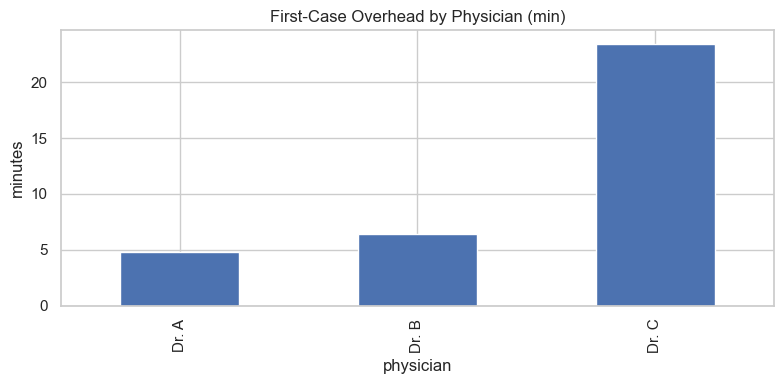

In [16]:
# 12) First-case overhead
# Extra time on first case of each physician-day versus later cases.

df_fc = df.dropna(subset=['date', 'physician', 'case_id', 'case_time']).copy()
df_fc = df_fc.sort_values(['date', 'physician', 'case_id'])
df_fc['doc_case_on_day'] = df_fc.groupby(['date', 'physician']).cumcount() + 1
df_fc['is_first_case'] = (df_fc['doc_case_on_day'] == 1).astype(int)

first_case_summary = (
    df_fc.assign(case_group=np.where(df_fc['is_first_case'] == 1, 'First', 'Later'))
    .groupby(['physician', 'case_group'])['case_time']
    .agg(['count', 'mean', 'median', 'std'])
    .round(2)
)
print('First vs later case summary (CASE TIME):')
display(first_case_summary)

overhead = (
    df_fc.groupby(['physician', 'is_first_case'])['case_time'].mean().unstack()
)
overhead.columns = ['later_mean_case_time', 'first_mean_case_time']
overhead['first_case_overhead_min'] = overhead['first_mean_case_time'] - overhead['later_mean_case_time']
overhead = overhead[['first_mean_case_time', 'later_mean_case_time', 'first_case_overhead_min']].round(2)

print('First-case overhead by physician (minutes):')
display(overhead)

ax = overhead['first_case_overhead_min'].plot(kind='bar', figsize=(8,4), title='First-Case Overhead by Physician (min)')
ax.set_xlabel('physician')
ax.set_ylabel('minutes')
plt.tight_layout()
plt.show()


Complexity share by physician:


,cases,complex_share_pct
physician,,
Dr. A,70,20.0
Dr. B,65,12.3
Dr. C,14,0.0


Complexity share by within-day case position:


,complex_share_pct
doc_case_on_day,
1,13.9
2,9.7
3,8.0
4,8.0
5,26.3
6,41.7
7,0.0


Complexity share by physician and month (%):


month,2025-01,2025-02,2025-03,2025-04,2025-05,2025-06,2025-07,2025-08,2025-09,2025-10
physician,,,,,,,,,,
Dr. A,0.0,0.0,NaN,0.0,0.0,8.3,16.7,33.3,31.6,50.0
Dr. B,0.0,0.0,0.0,0.0,12.5,22.2,15.4,15.4,25.0,0.0
Dr. C,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,NaN


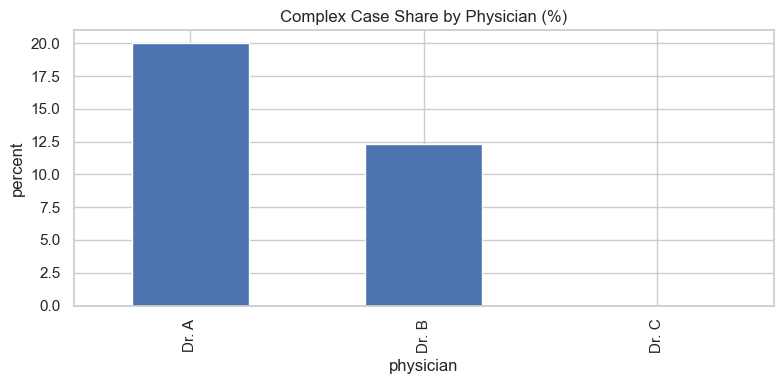

In [12]:
# 13) Complexity distribution
# Uses Note flags: CTI/BOX/PST/SVC/AAFL

df_cx = df.copy()
notes = df_cx['note'].fillna('').astype(str)
df_cx['is_complex'] = notes.str.contains('CTI|BOX|PST|SVC|AAFL', case=False, regex=True).astype(int)
df_cx['complexity_tag'] = np.where(df_cx['is_complex'] == 1, 'Complex/Non-standard', 'Standard PVI')

# Position within physician-day for distribution analysis
df_cx = df_cx.dropna(subset=['date', 'physician', 'case_id']).copy()
df_cx = df_cx.sort_values(['date', 'physician', 'case_id'])
df_cx['doc_case_on_day'] = df_cx.groupby(['date', 'physician']).cumcount() + 1

print('Complexity share by physician:')
phys_complex = (
    df_cx.groupby('physician')['is_complex']
    .agg(['count', 'mean'])
    .rename(columns={'count': 'cases', 'mean': 'complex_share'})
)
phys_complex['complex_share_pct'] = (phys_complex['complex_share'] * 100).round(1)
display(phys_complex[['cases', 'complex_share_pct']])

print('Complexity share by within-day case position:')
pos_complex = (
    df_cx.groupby('doc_case_on_day')['is_complex']
    .mean()
    .mul(100)
    .round(1)
    .to_frame('complex_share_pct')
)
display(pos_complex)

print('Complexity share by physician and month (%):')
by_month = (
    df_cx.assign(month=df_cx['date'].dt.to_period('M').astype(str))
    .groupby(['physician', 'month'])['is_complex']
    .mean()
    .mul(100)
    .round(1)
    .unstack(fill_value=np.nan)
)
display(by_month)

ax = phys_complex['complex_share_pct'].plot(kind='bar', figsize=(8,4), title='Complex Case Share by Physician (%)')
ax.set_ylabel('percent')
ax.set_xlabel('physician')
plt.tight_layout()
plt.show()


Complex-case counts:
physician
Dr. A    14
Dr. B     8
A vs B summary on complex cases:


case_time                      pt_in_out                        \
              count   mean median    std     count    mean median    std   
physician                                                                  
Dr. A            14  39.64   38.0   8.66        14   71.57   70.5   6.93   
Dr. B             7  78.43   69.0  37.30         7  121.29  112.0  39.22   

          skin_skin         ... la_dwell          tsp                      \
              count   mean  ...   median    std count   mean median   std   
physician                   ...                                             
Dr. A            14  44.29  ...     27.0   3.01    14   3.71    3.0  2.09   
Dr. B             7  83.71  ...     32.0  28.53     7  12.29    8.0  9.36   

          post_care_extubation                      
                         count   mean median   std  
physician                                           
Dr. A                       14  12.64   12.5  2.02  
Dr. B                        7  13.43   12.0  3.55  

[2 rows x 24 columns]

Mean difference (Dr. A - Dr. B) on complex cases:


,A_minus_B_mean_min
case_time,-38.79
pt_in_out,-49.71
skin_skin,-39.43
la_dwell,-20.43
tsp,-8.57
post_care_extubation,-0.79


Welch t-test results (complex cases only):


,metric,n_A,n_B,mean_A,mean_B,A_minus_B,p_value_welch
1,pt_in_out,14,7,71.5714,121.2857,-49.7143,0.0151
2,skin_skin,14,7,44.2857,83.7143,-39.4286,0.0329
0,case_time,14,7,39.6429,78.4286,-38.7857,0.0331
3,la_dwell,14,7,26.4286,46.8571,-20.4286,0.1072
4,tsp,14,7,3.7143,12.2857,-8.5714,0.0518
5,post_care_extubation,14,7,12.6429,13.4286,-0.7857,0.6020


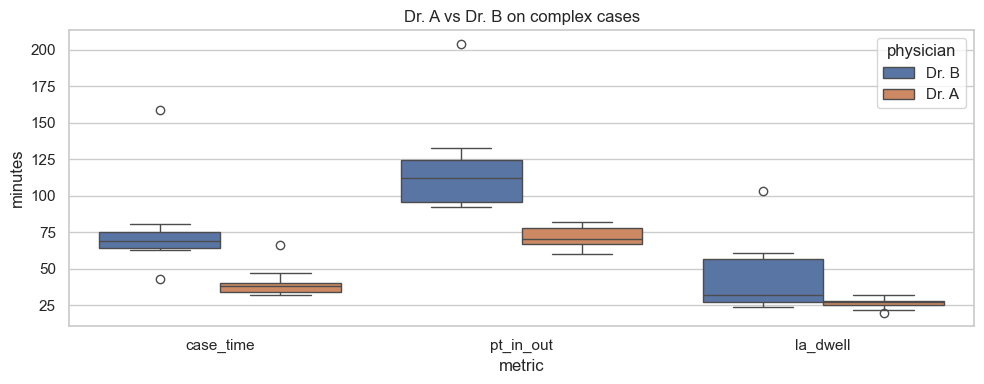

In [13]:
# 13b) Complex-case A vs B comparison
# Directly compare Dr. A vs Dr. B on complex/non-standard cases.

from scipy.stats import ttest_ind

df_ab = df.copy()
notes_ab = df_ab['note'].fillna('').astype(str)
df_ab['is_complex'] = notes_ab.str.contains('CTI|BOX|PST|SVC|AAFL|TROUBLE', case=False, regex=True).astype(int)

ab_complex = df_ab[(df_ab['physician'].isin(['Dr. A', 'Dr. B'])) & (df_ab['is_complex'] == 1)].copy()

metrics = ['case_time', 'pt_in_out', 'skin_skin', 'la_dwell', 'tsp', 'post_care_extubation']

print('Complex-case counts:')
print(ab_complex['physician'].value_counts().to_string())

summary_ab = (
    ab_complex.groupby('physician')[metrics]
    .agg(['count', 'mean', 'median', 'std'])
    .round(2)
)
print('A vs B summary on complex cases:')
display(summary_ab)

means_ab = ab_complex.groupby('physician')[metrics].mean().T
if {'Dr. A', 'Dr. B'}.issubset(set(means_ab.columns)):
    delta = (means_ab['Dr. A'] - means_ab['Dr. B']).to_frame('A_minus_B_mean_min').round(2)
    print('Mean difference (Dr. A - Dr. B) on complex cases:')
    display(delta)

# Welch t-test by metric for complex-case A vs B
rows = []
for m in metrics:
    a = ab_complex.loc[ab_complex['physician'] == 'Dr. A', m].dropna()
    b = ab_complex.loc[ab_complex['physician'] == 'Dr. B', m].dropna()
    if len(a) >= 2 and len(b) >= 2:
        stat, p = ttest_ind(a, b, equal_var=False, nan_policy='omit')
        rows.append({
            'metric': m,
            'n_A': len(a),
            'n_B': len(b),
            'mean_A': a.mean(),
            'mean_B': b.mean(),
            'A_minus_B': a.mean() - b.mean(),
            'p_value_welch': p,
        })

if rows:
    test_df = pd.DataFrame(rows).sort_values('A_minus_B').round(4)
    print('Welch t-test results (complex cases only):')
    display(test_df)

# Visual comparison for primary outcomes
plot_metrics = ['case_time', 'pt_in_out', 'la_dwell']
melt_ab = ab_complex[['physician'] + plot_metrics].melt(id_vars='physician', var_name='metric', value_name='minutes')
plt.figure(figsize=(10, 4))
sns.boxplot(data=melt_ab, x='metric', y='minutes', hue='physician')
plt.title('Dr. A vs Dr. B on complex cases')
plt.tight_layout()
plt.show()
